# Resources

[1. Tutorial on time delay cacluation](https://stackoverflow.com/questions/4967453/time-delay-estimation-between-two-audio-signals)

[2. Cone of confusion definition](https://hearinghealthmatters.org/waynesworld/2023/localization-more-important-than-word-recognition/)

[3. Sound triangulation theory and practice](https://encyclopedia.pub/entry/53167)

[4. How to calculate TDOA](https://stackoverflow.com/questions/52192584/clear-simple-example-of-how-to-calculate-tdoa-time-difference-of-arrival)

[5. Normalizing waveforms](https://dsp.stackexchange.com/questions/43907/normalizing-audio-waveforms-code-implementation-peak-rms)

In [3]:
from utils.imports import *
# 1. Define the path to your extracted ffmpeg bin folder
# (Change this to wherever you actually saved it)
ffmpeg_bin_path = r"D:\Programs\ffmpeg\ffmpeg-8.1.1-full_build-shared\bin"
# 2. Add it to the Windows PATH for this specific Python session
os.environ["PATH"] += os.pathsep + ffmpeg_bin_path
# 3. Tell Python where to look for DLLs (Required for Python 3.8+ on Windows)
if hasattr(os, 'add_dll_directory'):
    os.add_dll_directory(ffmpeg_bin_path)
# 4. NOW you can import torchaudio safely

# Utils

### 2.2.b,c)

In [4]:
dataset_roots:dict = [r'utils\assignment_2_dataset\train',
                      r'utils\assignment_2_dataset\validation',
                      r'utils\assignment_2_dataset\test']

In [5]:
@staticmethod
def visualize_waveforms(waveforms:tuple|list, reduce:int = 500)->None:

    for index, wave in enumerate(waveforms[0]):
        PLT.plot(wave[:500], label=f"{waveforms[1][index]}")
        PLT.xlabel("Sample index")
        PLT.ylabel("Amplitude")
        PLT.legend()
        PLT.grid()
    
    PLT.show()
        
    return None

In [6]:
@staticmethod
def audio_simulator(input, source_loc:tuple, mic_locs:list|tuple):
    """
    Def:
    :params input
    :params tuple of floats source_loc: Holding the cartesian coordinates of the source; 
    :params list of tuples mic_locs: Holding the cartesian coordinates of multiple microphones. If all the microphones share the same location then the argument becomes a tuple

    Return: waveforms (visualiazation) and time_delays
    """

    def _time_delay_calculation(mic=mic_locs, source=source_loc, common_loc=False):
        for locations in mic:
            relative_time_delays.append(np.round((np.sqrt( (source[0]-locations[0])**2 + (source[1]-locations[1])**2)/c)*sr))

        # 2. Locate the furthest situated microphone by time_delay: the more samples, the furthest
        furtherst = max(relative_time_delays)
        for relative_time in relative_time_delays:
            delay = furtherst-relative_time
            waveforms.append(input[int(delay):])
    
    c:int=340*100
    sr:int = 48000
    relative_time_delays:list = []
    time_delay_of_arival:int = 0
    waveforms:list = []

    if isinstance(mic_locs, tuple):
        _time_delay_calculation(True)
    elif isinstance(mic_locs, list):
        _time_delay_calculation()
    
    
    return waveforms, relative_time_delays

Initial signal shape torch.Size([2, 113669])
Preprocessed signal shape torch.Size([113669]) with relative time delays [np.float64(326.0), np.float64(306.0)] and lenghts 113669; 113649


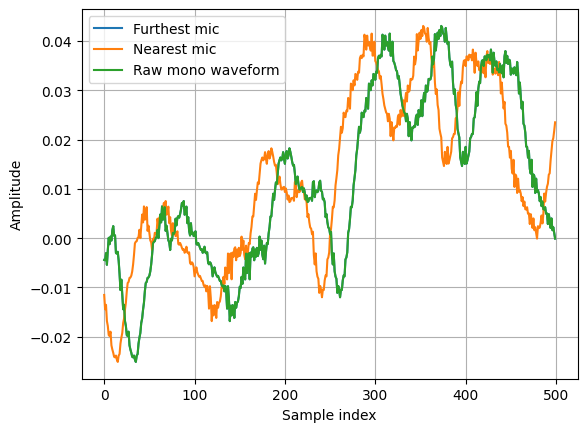

In [7]:
# 1. Loading the signal (e.g., mp3 track)
waveform, sample_rate = torchaudio.load(r'utils\assignment_2_dataset\train\bird1.mp3')
# 2. Averaging out the signal's channels - THIS IS A PREPROCESSING STEP w
mono_waveform = torch.mean(waveform, dim=0)
# 3. Calculating the time delay differences and outputting the new waveforms
waveforms, relative_time_delays = audio_simulator(input=mono_waveform, source_loc=(200, 100), mic_locs=[(-8, 0),(8, 0)])


# Informative print
print("Initial signal shape {}\nPreprocessed signal shape {} with relative time delays {} and lenghts {}; {}".format(waveform.shape, mono_waveform.shape, relative_time_delays, len(waveform[0]), len(waveforms[1])))
input_for_vis = [[waveforms[0], waveforms[1],mono_waveform],["Furthest mic","Nearest mic","Raw mono waveform"]]
visualize_waveforms(input_for_vis)

Initial signal shape torch.Size([2, 113669])
Preprocessed signal shape torch.Size([113669]) with relative time delays [np.float64(374.0), np.float64(335.0), np.float64(297.0), np.float64(260.0)]


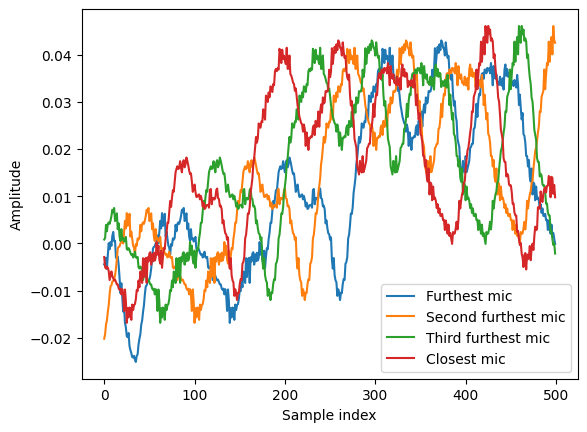

In [8]:
waveforms, relative_time_delays = audio_simulator(input=mono_waveform, source_loc=(200, 100), mic_locs=[(-45, 0),(-15, 0), (15, 0), (45, 0)])
print("Initial signal shape {}\nPreprocessed signal shape {} with relative time delays {}".format(waveform.shape, mono_waveform.shape, relative_time_delays))
input_for_vis = [[waveforms[0], waveforms[1], waveforms[2], waveforms[3]],["Furthest mic","Second furthest mic","Third furthest mic","Closest mic"]]
visualize_waveforms(input_for_vis)


### 2.2.e)

In [9]:
# 1. Calculating the sample difference between the furthest and nearest mics
sample_difference = max(relative_time_delays) - min(relative_time_delays) 
time_difference_seconds = sample_difference / sample_rate
print(f"For a sample differnece of {sample_difference} and smapling rate {sample_rate} the time difference: {time_difference_seconds:.5f} seconds")

print(relative_time_delays)

# t = m/d

For a sample differnece of 114.0 and smapling rate 48000 the time difference: 0.00237 seconds
[np.float64(374.0), np.float64(335.0), np.float64(297.0), np.float64(260.0)]


### 2.2.g)

In [ ]:
class CustomAudioDecoderData(Dataset):
    """
    :param float t:
    :param list of integers mic_locs:
    :param tuple holding float values n_sources_min_max:
    ....
    """
    def __init__(self, t, mic_locs, n_sources_min, n_sources_max, x_loc_min, x_loc_max, y_loc_min, y_loc_max, split='train', data_folder=dataset_roots, transforms = None):

        # 1.1 Fail save, ensuring NO-CAPITAL charachters are accidentally inserted;        
        self.split = split.lower()
        # 1.2 Map split string to the correct index of data_folder (0=train, 1=val, 2=test)
        split_mapping = {'train': 0, 'val': 1, 'test': 2}
        if self.split not in split_mapping:
            raise ValueError("split must be 'train', 'val', or 'test'")
        # 1.3 Set a value (e.g., 0, 1 or 2) based on the subset of interest specified at class instantiation time;
        self.split_idx = split_mapping[self.split]

        self.dataset_root_paths = data_folder
        self.transform = transforms
        self.end_time = t/1000 
        self.mic_locs = mic_locs
        self.n_sources = (n_sources_min, n_sources_max)
        self.x_y_min_max = (x_loc_min, x_loc_max, y_loc_min, y_loc_max)

        # 1. Collecting data paths
        all_data_paths = self._retrieve_and_assemble_data_paths()

        # 2. Declare active file paths based on step `1.3`
        self.active_paths = all_data_paths[self.split_idx]
    
    def __len__(self):
        return len(self.active_paths)

    def __getitem__(self, idx):

        # 3.1 Determine how many sources;
        n_sources = rdm.randint(self.n_sources[0], self.n_sources[1])
        # 3.2 Create data holders aka containers;
        all_simulated_waveforms, source_locations = [], []
        # 4. Loop over sources
        for _ in range(n_sources):
            # 4.1 Target a single file path string using the index [1] and a randomly chosen index [rdm]
            if _ == 0:
                file_path = self.active_paths[idx]
            else:
                file_path = rdm.choice(self.active_paths)
            # 4.2 Assign and save/append the randomly generated coordinates of the sources
            x, y = rdm.uniform(self.x_y_min_max[0], self.x_y_min_max[1]), rdm.uniform(self.x_y_min_max[2], self.x_y_min_max[3])
            source_locations.append((x,y))
            # 4.3 Safely instantiate AudioDecoder with a single string path [1]
            decoder = AudioDecoder(file_path)
            if self.transform:
                print("Preprocessing data...")
                # 4.4 Extract audio tensor stream and cut adequately
                waveform = decoder.get_samples_played_in_range(start_seconds=0, stop_seconds=self.end_time) # Length of the returned sample
                #TODO Implement if statement to check for the number of channels
                mono = torch.mean(waveform.data, dim=0) # Averaging the waveform holding at least two channels
                waveforms, delays = audio_simulator(mono, source_loc=(x, y), mic_locs=self.mic_locs) 
                # 4.4.1 Find the samllest length in the list of waveforms
                # ... then use it as a refference for a clamping threshold
                min_length = min([w.shape[0] for w in waveforms])
                # 4.4.2 Trim every waveform to match that minimum length
                trimmed_waveforms = [w[:min_length] for w in waveforms] # Shape waveforms:  [torch.tensor(simmulated waveform) for wave in range(no. mics)]
                # 4.4.3 Stack the trimmed waveforms                     # 
                source_tensor = torch.stack(trimmed_waveforms) # Shape: [n_mics, samples]
                all_simulated_waveforms.append(source_tensor)
                # # Debug statement 2
                # print("Waveform-decoder shape {}\n"
                # "Waveforms-decoder after mono p[ shape {}\n" \
                # "Waveforms after audio simulator and trimming {} plus size of each element {}\n" \
                # "First stacking (torch.stack(trimmed_waveforms)): {}" \
                # "".format(waveform.data.shape, mono.shape, 
                #             len(trimmed_waveforms),(trimmed_waveforms[0].shape, 
                #                                     trimmed_waveforms[1].shape),
                #                                     source_tensor.shape))

        # 5. After the 'for' loop ends:
        stacked_tensor = torch.stack(all_simulated_waveforms) # Shape: [n_sources, n_mics, samples]
        print("Second stacking:",stacked_tensor.shape)
        mixed_tensor = torch.sum(stacked_tensor, dim=0)       # Shape: [n_mics, samples]
        print("Third stacking:",mixed_tensor.shape)
        # Informative staement
        print("Source tensor shape {} Stacked tensor shape {} Source locations {}".format(source_tensor.shape, stacked_tensor.shape, source_locations))
        
        return source_tensor, stacked_tensor, source_locations
  
    def _retrieve_and_assemble_data_paths(self, info:bool=False):
        # 0. Declaring path containers;
        _p_dataset:list = []
        # 1. Determining the number of data sets we're interested in
        # ... commonly stays 3: train, test, val;
        for set in range(len(dataset_roots)):
            # 1.1. Retriveing the .mp3 file names
            names = os.listdir(self.dataset_root_paths[set])
            _p_dataset.append([os.path.join(self.dataset_root_paths[set],item) for item in names])

        if info:
            print(f"Container holding pahts to .mp3 files holds the following content {_p_dataset}")

        return _p_dataset


In [106]:
train_dataset=CustomAudioDecoderData(t=100,n_sources_min=1, n_sources_max=1, x_loc_min=-200, x_loc_max=200,y_loc_max=200,y_loc_min=25, split='train',mic_locs=[(-8, 0), (8, 0)], data_folder=dataset_roots, transforms=True)
val_dataset=CustomAudioDecoderData(t=100,n_sources_min=1, n_sources_max=1, x_loc_min=-200, x_loc_max=200,y_loc_max=200,y_loc_min=25, split='val',mic_locs=[(-8, 0), (8, 0)], data_folder=dataset_roots, transforms=True)
test_dataset=CustomAudioDecoderData(t=100,n_sources_min=1, n_sources_max=1, x_loc_min=-200, x_loc_max=200,y_loc_max=200,y_loc_min=25, split='test',mic_locs=[(-8, 0), (8, 0)], data_folder=dataset_roots, transforms=True)

# Informational print statement
print("Train length: {}\nVal length: {}\nTest length: {}" \
"\nGeneric test-related content: {}".format(len(train_dataset), len(val_dataset), len(test_dataset), next(enumerate(train_dataset))))


Preprocessing data...
Second stacking: torch.Size([1, 2, 3680])
Third stacking: torch.Size([2, 3680])
Source tensor shape torch.Size([2, 3680]) Stacked tensor shape torch.Size([1, 2, 3680]) Source locations [(102.5213502804225, 126.97792028864073)]
Train length: 28
Val length: 4
Test length: 4
Generic test-related content: (0, (tensor([[-0.0044, -0.0045, -0.0030,  ..., -0.0186, -0.0190, -0.0160],
        [-0.0028, -0.0046, -0.0073,  ..., -0.0117, -0.0119, -0.0132]]), tensor([[[-0.0044, -0.0045, -0.0030,  ..., -0.0186, -0.0190, -0.0160],
         [-0.0028, -0.0046, -0.0073,  ..., -0.0117, -0.0119, -0.0132]]]), [(102.5213502804225, 126.97792028864073)]))
